# EDA: Final ILCS household dataset (research columns)

Exploratory data analysis of **`ml_households_research_columns_imputed.csv`**: the **27–28 research columns only**, after **KNN imputation (k=9)**. In the pipeline we **only** impute this extracted subset—not the full 61-column table. This file is produced by the **t-SNE notebook** (step 5: KNN on 27–28 research columns → save → standardize → t-SNE). **Run the t-SNE notebook through step 5 first** to generate it; then EDA uses complete data with no missing values.

**Logic of the ~27 research columns:** They are the subset defined in `data/ilcs/final_dropped/columns.txt`: every column marked with **+** or in the **(++++) Income & consumption** block—one or two variables per theme (household structure, assets, housing quality, debt & transfers, vulnerability & benefits, income & consumption). This file has **no** `region_label`, `area_type_label`, `tsne_1`, `tsne_2`, or `cluster` (those exist only in the full pipeline for visualization).

## 1. Load and overview

In [57]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
# Imputed research columns (KNN k=9) — produced by t-SNE notebook step 4/5
FINAL_CSV = DATA_DIR / "research" / "ml_households_research_columns_imputed.csv"
if not FINAL_CSV.exists():
    raise FileNotFoundError(
        f"Not found: {FINAL_CSV}. Run the t-SNE notebook through step 5 (feature matrix) first to create the imputed research file."
    )
df = pd.read_csv(FINAL_CSV, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns (imputed; no missing)")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
missing = df.isna().sum()
print(f"\nMissing per column (count):\n{missing[missing > 0] if missing.gt(0).any() else 'None'}")
print(f"\nAll columns ({len(df.columns)}):", list(df.columns))

Shape: 5,184 rows × 28 columns (imputed; no missing)

Column dtypes:
float64    28
Name: count, dtype: int64

Missing per column (count):
None

All columns (28): ['household_size', 'dwelling_ownership', 'number_of_rooms', 'has_computer', 'has_other_dwelling', 'household_has_car', 'potable_water_hours_day', 'heating_spend_last_winter_amd', 'dwelling_condition_estimate', 'dwelling_renovated', 'building_new_house', 'household_sent_money_goods_12m', 'household_received_money_goods_12m', 'lent_money_12m', 'family_debt_amount', 'borrowed_money_12m', 'registered_poverty_benefit', 'share_families_really_vulnerable', 'humanitarian_assistance_12m', 'money_family_need_monthly_live', 'drm_in_amd', 'money_family_need_monthly_make', 'amd_3', 'household_income_total', 'household_income_source_count', 'food_purchases_total', 'services_goods_total', 'goods_services_total']


In [ ]:

# ── Human-readable labels for all 28 research columns ──────────────────────
LABEL_MAP = {
    'household_size':                   'Household Size (# members)',
    'dwelling_ownership':               'Dwelling Ownership (1=Own, 2=Rent…)',
    'number_of_rooms':                  'Number of Rooms',
    'has_computer':                     'Has Computer (1=Yes, 2=No)',
    'has_other_dwelling':               'Has Another Dwelling (1=Yes, 2–4=No)',
    'household_has_car':                'Has Car (1=Yes, 2=No)',
    'potable_water_hours_day':          'Potable Water Hours per Day',
    'heating_spend_last_winter_amd':    'Heating Spend Last Winter (AMD)',
    'dwelling_condition_estimate':      'Dwelling Condition (1=Poor → 5=Excellent)',
    'dwelling_renovated':               'Dwelling Renovated (1=Yes, 2=No, 3=Long ago)',
    'building_new_house':               'Building New House (1=Yes, 2=No)',
    'household_sent_money_goods_12m':   'Sent Money/Goods Past 12m (1=Yes, 2=No)',
    'household_received_money_goods_12m': 'Received Money/Goods Past 12m (1=Yes, 2=No)',
    'lent_money_12m':                   'Lent Money Past 12m (1=Yes, 2=No)',
    'family_debt_amount':               'Family Debt Amount (AMD)',
    'borrowed_money_12m':               'Borrowed Money Past 12m (1=Yes, 2=No)',
    'registered_poverty_benefit':       'Poverty Benefit Status (1=Receiving → 4=Never)',
    'share_families_really_vulnerable': 'Share Truly Vulnerable Families (1=None → 6=All)',
    'humanitarian_assistance_12m':      'Received Humanitarian Aid Past 12m (1=Yes, 2=No)',
    'money_family_need_monthly_live':   'Monthly Income Needed to Live Well (AMD)',
    'drm_in_amd':                       'Minimum Subsistence — DRM (AMD)',
    'money_family_need_monthly_make':   'Monthly Income to Make Ends Meet (1–4)',
    'amd_3':                            'Subjective Min. Income — Survive (AMD)',
    'household_income_total':           'Total Household Income (AMD)',
    'household_income_source_count':    'Number of Income Sources',
    'food_purchases_total':             'Food Purchases Total (AMD)',
    'services_goods_total':             'Services & Goods Spending (AMD)',
    'goods_services_total':             'Goods & Services Total (AMD)',
}

# Columns that are binary/ordinal codes → bar chart (not histogram)
CATEGORICAL_COLS = {
    'has_computer', 'household_has_car', 'dwelling_renovated', 'building_new_house',
    'household_sent_money_goods_12m', 'household_received_money_goods_12m',
    'lent_money_12m', 'borrowed_money_12m', 'humanitarian_assistance_12m',
    'dwelling_ownership', 'dwelling_condition_estimate', 'registered_poverty_benefit',
    'has_other_dwelling', 'money_family_need_monthly_make',
}

# Monetary AMD columns → log-scale Y on horizontal histograms
LOG_SCALE_COLS = {
    'heating_spend_last_winter_amd', 'family_debt_amount',
    'money_family_need_monthly_live', 'drm_in_amd', 'amd_3',
    'household_income_total', 'food_purchases_total',
    'services_goods_total', 'goods_services_total',
}

def col_label(col):
    """Return human-readable axis label for a column."""
    return LABEL_MAP.get(col, col.replace('_', ' ').title())


## 2. Numeric summary

In [58]:
numeric = df.select_dtypes(include=[np.number])
print("Numeric columns:", numeric.shape[1])
numeric.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

Numeric columns: 28


,count,mean,std,min,50%,max
household_size,5184.0,3.70,1.88,1.0,4.00,19.00
dwelling_ownership,5184.0,1.22,0.76,1.0,1.00,5.00
number_of_rooms,5184.0,3.06,1.20,1.0,3.00,10.00
has_computer,5184.0,1.41,0.49,1.0,1.00,2.00
has_other_dwelling,5184.0,3.93,0.38,1.0,4.00,4.00
household_has_car,5184.0,1.69,0.46,1.0,2.00,2.00
potable_water_hours_day,5184.0,29.73,3.07,3.0,30.67,31.00
heating_spend_last_winter_amd,5184.0,103240.66,61749.94,7.0,100000.00,600000.00
dwelling_condition_estimate,5184.0,3.07,0.70,1.0,3.00,5.00
dwelling_renovated,5184.0,2.44,0.55,1.0,2.00,3.00


## 3. Key categorical / grouping variables

*(Research set has no region_label, area_type_label, or cluster; we show value counts for low-cardinality numeric columns.)*

In [59]:
# Preferred grouping cols (only in full/final_dropped, not in research set)
group_cols = ["region_label", "area_type_label", "cluster"]
existing = [c for c in group_cols if c in df.columns]
if existing:
    for col in existing:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).to_string())
else:
    print("Research set has no region_label, area_type_label, or cluster.")
    low_card = [c for c in df.columns if df[c].nunique() <= 12 and df[c].dtype in ("int64", "float64")]
    for col in low_card[:10]:
        print(f"\n--- {col} (nunique={df[col].nunique()}) ---")
        print(df[col].value_counts(dropna=False).head(15).to_string())

Research set has no region_label, area_type_label, or cluster.

--- dwelling_ownership (nunique=5) ---
dwelling_ownership
1.0    4745
3.0     246
5.0     124
2.0      40
4.0      29

--- number_of_rooms (nunique=11) ---
number_of_rooms
3.0     1863
2.0     1176
4.0     1153
1.0      466
5.0      381
6.0      103
7.0       25
8.0       13
9.0        2
10.0       1
1.5        1

--- has_computer (nunique=2) ---
has_computer
1.0    3082
2.0    2102

--- has_other_dwelling (nunique=4) ---
has_other_dwelling
4.0    4990
2.0     139
3.0      36
1.0      19

--- household_has_car (nunique=2) ---
household_has_car
2.0    3566
1.0    1618

--- dwelling_condition_estimate (nunique=5) ---
dwelling_condition_estimate
3.0    3191
4.0     921
2.0     876
5.0     176
1.0      20

--- dwelling_renovated (nunique=3) ---
dwelling_renovated
2.0    2642
3.0    2404
1.0     138

--- building_new_house (nunique=2) ---
building_new_house
2.0    5174
1.0      10

--- household_sent_money_goods_12m (nunique=2)

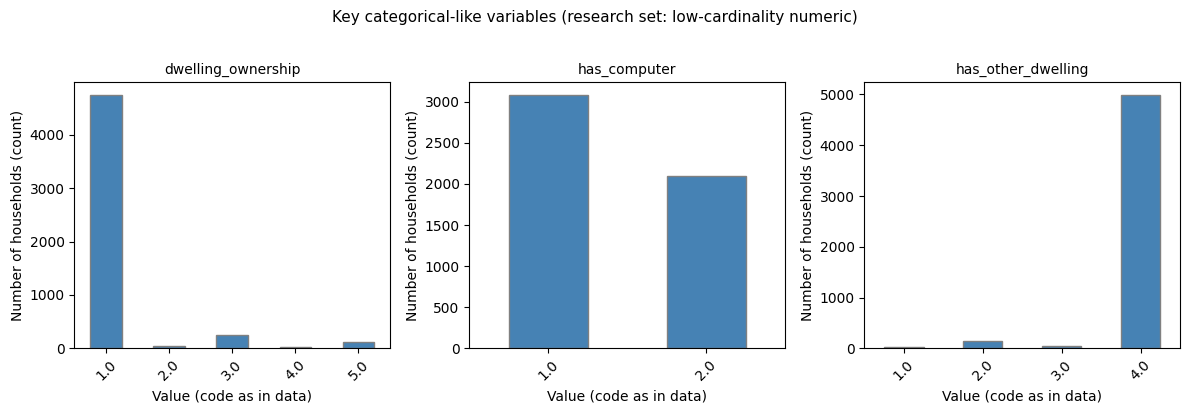

In [60]:
group_cols = ["region_label", "area_type_label", "cluster"]
existing = [c for c in group_cols if c in df.columns]
if existing:
    n = len(existing)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle("Key categorical / grouping variables (region, area type, cluster)", fontsize=11, y=1.02)
    axes = [axes] if n == 1 else axes
    for ax, col in zip(axes, existing):
        df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="gray")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Category (label or code as in data)")
        ax.set_ylabel("Number of households (count)")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    low_card = [c for c in df.columns if df[c].nunique() <= 10 and df[c].dtype in ("int64", "float64")][:3]
    if low_card:
        fig, axes = plt.subplots(1, len(low_card), figsize=(4 * len(low_card), 4))
        fig.suptitle("Key categorical-like variables (research set: low-cardinality numeric)", fontsize=11, y=1.02)
        axes = [axes] if len(low_card) == 1 else axes
        for ax, col in zip(axes, low_card):
            df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="gray")
            ax.set_title(col, fontsize=10)
            ax.set_xlabel("Value (code as in data)")
            ax.set_ylabel("Number of households (count)")
            ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No low-cardinality columns to plot.")

In [61]:
# (Section 4 below)

## 4. Income and poverty-related variables

In [ ]:
income_cols = [
    "household_income_total", "food_purchases_total", "services_goods_total",
    "money_family_need_monthly_live", "drm_in_amd", "registered_poverty_benefit",
]
income_cols = [c for c in income_cols if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle("Income and Poverty-Related Variables — Distributions", fontsize=13, y=1.01)
axes = axes.ravel()

for i, col in enumerate(income_cols):
    ax = axes[i]
    ser = df[col].dropna()
    label = col_label(col)

    if col in CATEGORICAL_COLS or ser.nunique() <= 10:
        # Bar chart for ordinal / categorical codes
        ser.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_xlabel(label)
        ax.set_ylabel('Number of Households')
        ax.tick_params(axis='x', rotation=45)
    else:
        # Horizontal histogram — value on Y axis (log-scaled for AMD cols)
        ser_pos = ser[ser > 0] if col in LOG_SCALE_COLS else ser
        ax.hist(ser_pos, bins=60, orientation='horizontal',
                color='steelblue', edgecolor='white', alpha=0.85)
        if col in LOG_SCALE_COLS and len(ser_pos) > 0:
            ax.set_yscale('log')
        ax.set_ylabel(label)
        ax.set_xlabel('Number of Households')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

for j in range(len(income_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


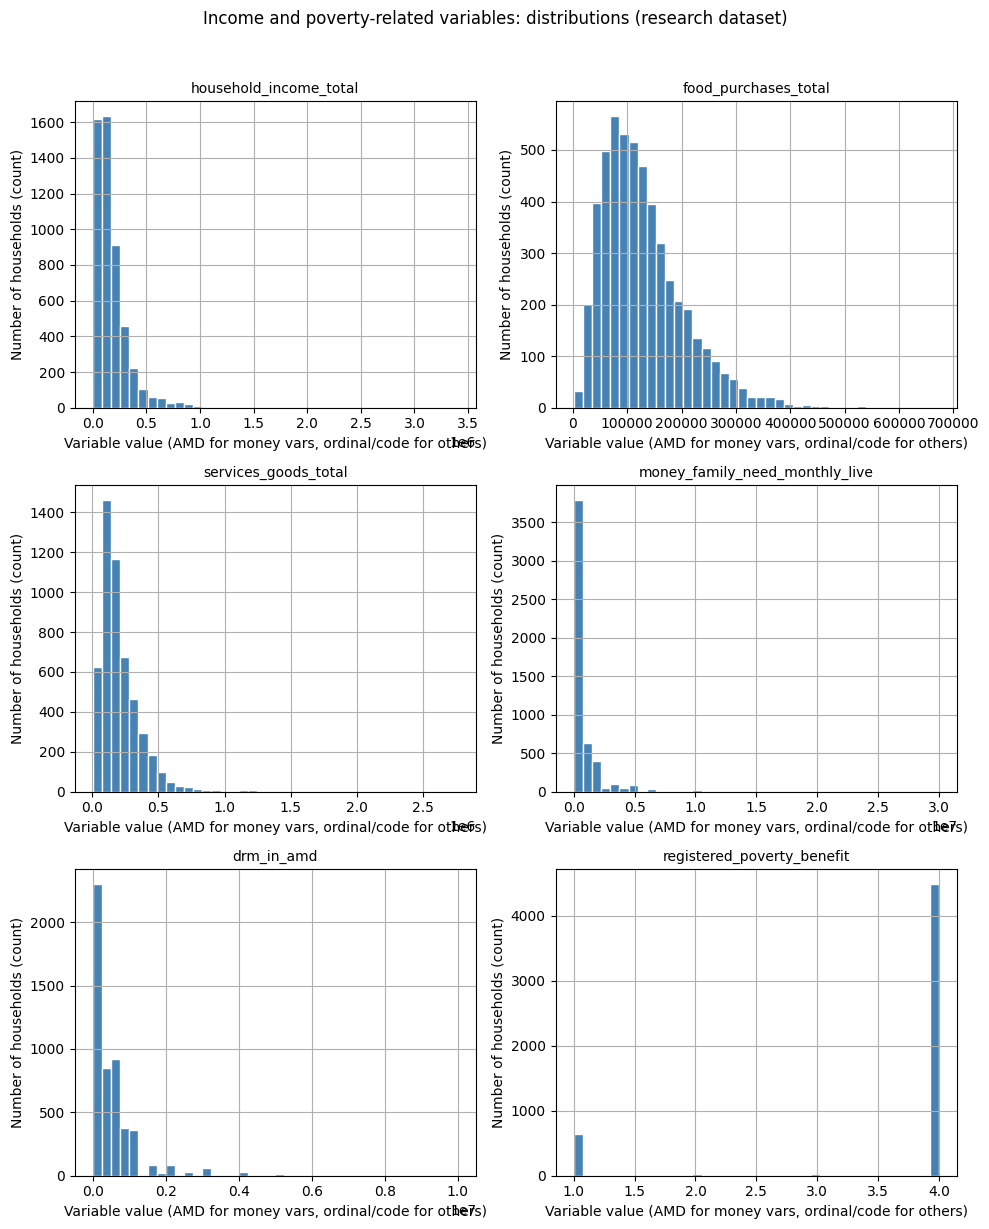

In [63]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("Income and poverty-related variables: distributions (research dataset)", fontsize=12, y=1.02)
axes = axes.ravel()  # 2 plots per row
for i, col in enumerate(income_cols):
    if col in df.columns and df[col].dtype in [np.float64, np.int64]:
        ax = axes[i]
        df[col].dropna().hist(ax=ax, bins=40, color="steelblue", edgecolor="white")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Variable value (AMD for money vars, ordinal/code for others)")
        ax.set_ylabel("Number of households (count)")
for j in range(len(income_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Assets and housing (selected)

Summary statistics and distributions for asset/housing variables.

In [ ]:
asset_cols = [
    "household_size", "number_of_rooms", "household_has_car",
    "has_computer", "dwelling_ownership", "dwelling_condition_estimate",
]
asset_cols = [c for c in asset_cols if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle("Assets and Housing — Distributions", fontsize=13, y=1.01)
axes = axes.ravel()

for i, col in enumerate(asset_cols):
    ax = axes[i]
    ser = df[col].dropna()
    label = col_label(col)

    if col in CATEGORICAL_COLS or ser.nunique() <= 12:
        # Bar chart for binary / ordinal codes (1=Yes/No, condition ratings, etc.)
        ser.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_xlabel(label)
        ax.set_ylabel('Number of Households')
        ax.tick_params(axis='x', rotation=45)
    else:
        # Horizontal histogram for true continuous columns (e.g. household_size)
        ax.hist(ser, bins=40, orientation='horizontal',
                color='steelblue', edgecolor='white', alpha=0.85)
        ax.set_ylabel(label)
        ax.set_xlabel('Number of Households')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

for j in range(len(asset_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


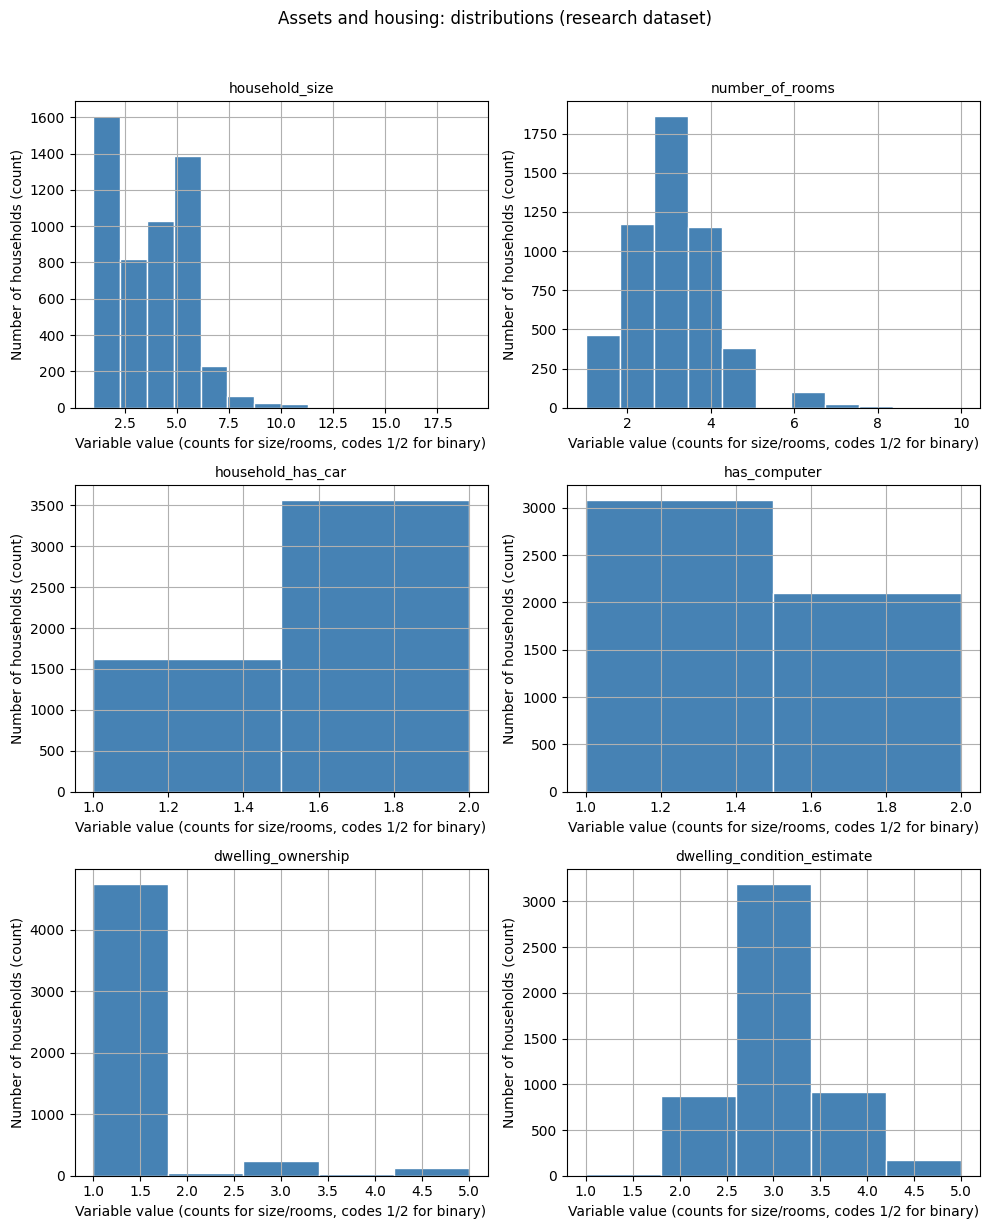

In [65]:
# Asset and housing variables: distributions (research dataset)
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("Assets and housing: distributions (research dataset)", fontsize=12, y=1.02)
axes = axes.ravel()  # 2 plots per row
for i, col in enumerate(asset_cols):
    if col in df.columns and i < len(axes):
        ax = axes[i]
        df[col].dropna().hist(ax=ax, bins=min(30, df[col].nunique()), color="steelblue", edgecolor="white")
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Variable value (counts for size/rooms, codes 1/2 for binary)")
        ax.set_ylabel("Number of households (count)")
for j in range(len(asset_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Correlation (key numeric, excluding IDs and derived)

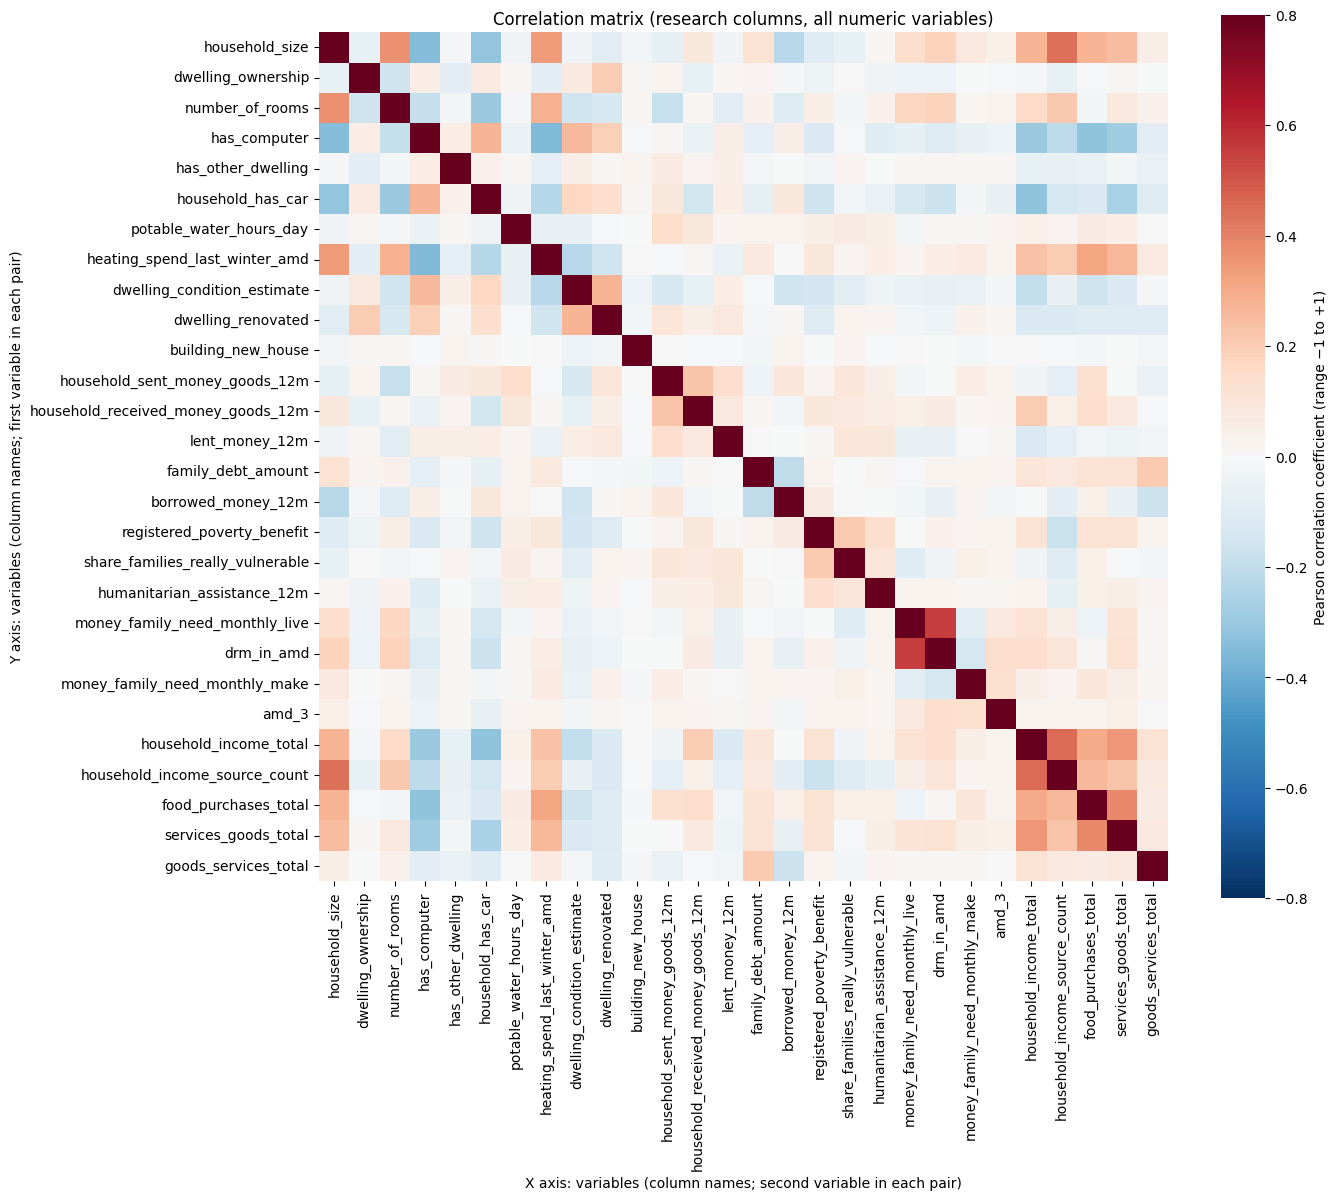

In [66]:
exclude = {"recno", "date", "year", "weight", "sample_weight", "tsne_1", "tsne_2", "cluster"}
num_for_corr = [c for c in numeric.columns if c not in exclude]
corr = df[num_for_corr].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8, ax=ax, square=True,
            cbar_kws={"label": "Pearson correlation coefficient (range −1 to +1)"})
ax.set_title("Correlation matrix (research columns, all numeric variables)")
ax.set_xlabel("X axis: variables (column names; second variable in each pair)")
ax.set_ylabel("Y axis: variables (column names; first variable in each pair)")
plt.tight_layout()
plt.show()

## 6b. Missing values by column (research dataset)

In [67]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.35)))
    missing.plot(kind="barh", ax=ax, color="coral", edgecolor="gray")
    ax.set_title("Missing value count by column (research dataset)")
    ax.set_xlabel("Number of missing values (count of NaN per column)")
    ax.set_ylabel("Column name (variable)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in the research dataset.")

No missing values in the research dataset.


plot_df = df[["household_income_total", "food_purchases_total", "services_goods_total"]].dropna()
if len(plot_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Consumption vs Household Income (log-log scale)", fontsize=12, y=1.02)

    # Left: food purchases (X) → income (Y)
    axes[0].scatter(
        plot_df["food_purchases_total"], plot_df["household_income_total"],
        alpha=0.3, s=10, c="steelblue"
    )
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel(col_label('food_purchases_total'))
    axes[0].set_ylabel(col_label('household_income_total'))
    axes[0].set_title("Food Purchases vs Household Income")
    axes[0].grid(alpha=0.3)

    # Right: services/goods (X) → income (Y)
    axes[1].scatter(
        plot_df["services_goods_total"], plot_df["household_income_total"],
        alpha=0.3, s=10, c="darkgreen"
    )
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(col_label('services_goods_total'))
    axes[1].set_ylabel(col_label('household_income_total'))
    axes[1].set_title("Services & Goods vs Household Income")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


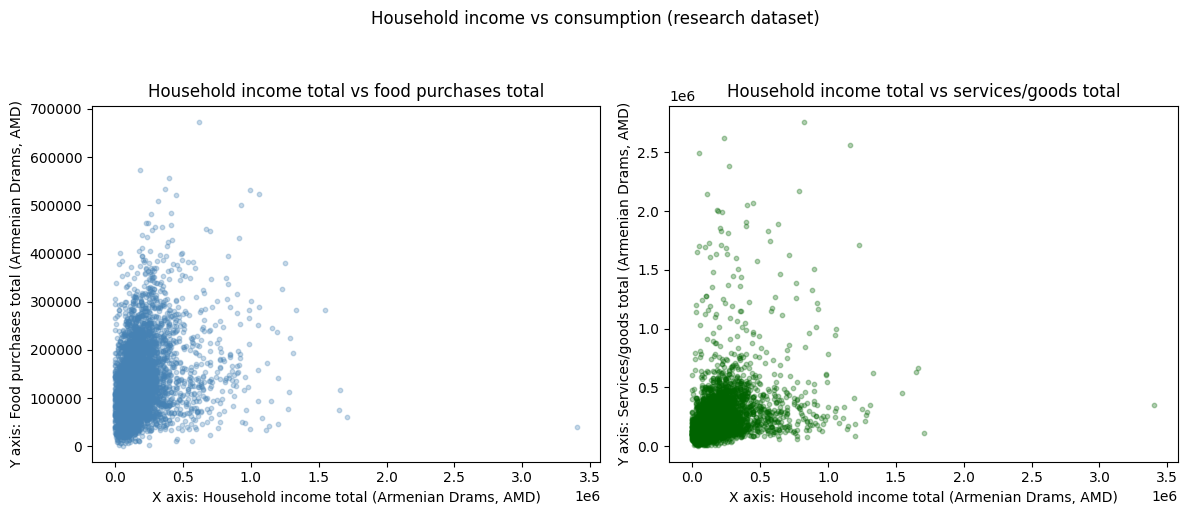

In [68]:
# Scatter: total household income vs food purchases and vs services/goods
plot_df = df[["household_income_total", "food_purchases_total", "services_goods_total"]].dropna()
if len(plot_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Household income vs consumption (research dataset)", fontsize=12, y=1.02)
    axes[0].scatter(plot_df["household_income_total"], plot_df["food_purchases_total"], alpha=0.3, s=10, c="steelblue")
    axes[0].set_title("Household income total vs food purchases total")
    axes[0].set_xlabel("X axis: Household income total (Armenian Drams, AMD)")
    axes[0].set_ylabel("Y axis: Food purchases total (Armenian Drams, AMD)")
    axes[1].scatter(plot_df["household_income_total"], plot_df["services_goods_total"], alpha=0.3, s=10, c="darkgreen")
    axes[1].set_title("Household income total vs services/goods total")
    axes[1].set_xlabel("X axis: Household income total (Armenian Drams, AMD)")
    axes[1].set_ylabel("Y axis: Services/goods total (Armenian Drams, AMD)")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Household Income by Key Asset Ownership (log scale)", fontsize=13, y=1.02)

if "household_has_car" in df.columns and "household_income_total" in df.columns:
    sns.boxplot(data=df, x="household_has_car", y="household_income_total",
                ax=axes[0], palette="Set2")
    axes[0].set_yscale('log')
    axes[0].set_title("Income by Car Ownership")
    axes[0].set_xlabel("Has Car (1=Yes, 2=No)")
    axes[0].set_ylabel(col_label('household_income_total'))
    axes[0].grid(axis='y', alpha=0.3)

if "has_computer" in df.columns and "household_income_total" in df.columns:
    sns.boxplot(data=df, x="has_computer", y="household_income_total",
                ax=axes[1], palette="Set3")
    axes[1].set_yscale('log')
    axes[1].set_title("Income by Computer Ownership")
    axes[1].set_xlabel("Has Computer (1=Yes, 2=No)")
    axes[1].set_ylabel(col_label('household_income_total'))
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/fc/lwvylwmj7pv7s7fg_03by4800000gn/T/ipykernel_63532/4176536534.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="household_has_car", y="household_income_total", ax=axes[0], palette="Set2")
/var/folders/fc/lwvylwmj7pv7s7fg_03by4800000gn/T/ipykernel_63532/4176536534.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="has_computer", y="household_income_total", ax=axes[1], palette="Set3")


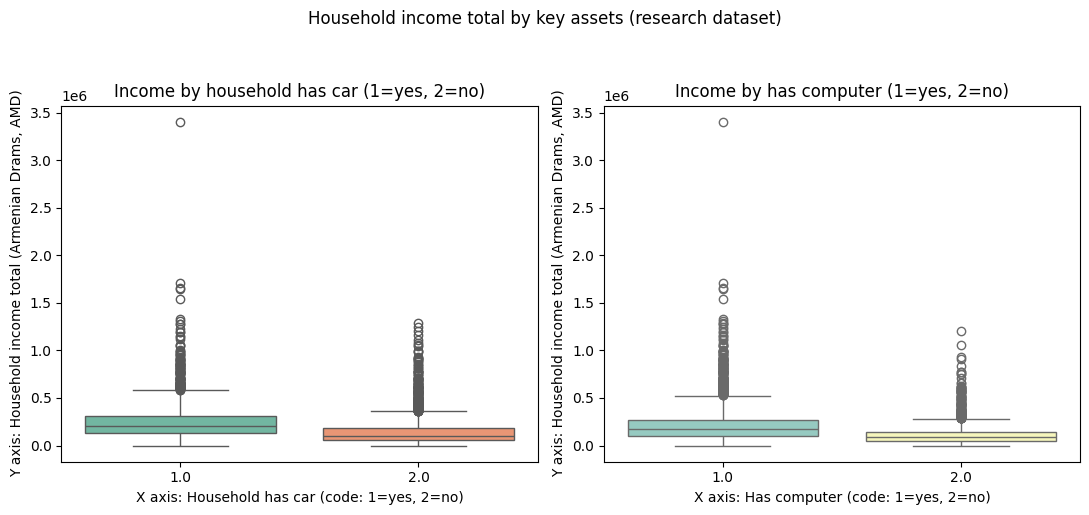

In [69]:
# Boxplots: household_income_total by household_has_car and by has_computer
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Household income total by key assets (research dataset)", fontsize=12, y=1.02)
if "household_has_car" in df.columns and "household_income_total" in df.columns:
    sns.boxplot(data=df, x="household_has_car", y="household_income_total", ax=axes[0], palette="Set2")
    axes[0].set_title("Income by household has car (1=yes, 2=no)")
    axes[0].set_xlabel("X axis: Household has car (code: 1=yes, 2=no)")
    axes[0].set_ylabel("Y axis: Household income total (Armenian Drams, AMD)")
if "has_computer" in df.columns and "household_income_total" in df.columns:
    sns.boxplot(data=df, x="has_computer", y="household_income_total", ax=axes[1], palette="Set3")
    axes[1].set_title("Income by has computer (1=yes, 2=no)")
    axes[1].set_xlabel("X axis: Has computer (code: 1=yes, 2=no)")
    axes[1].set_ylabel("Y axis: Household income total (Armenian Drams, AMD)")
plt.tight_layout()
plt.show()

vuln_cols = [
    "registered_poverty_benefit", "share_families_really_vulnerable",
    "humanitarian_assistance_12m", "family_debt_amount", "borrowed_money_12m",
]
vuln_cols = [c for c in vuln_cols if c in df.columns]

if vuln_cols:
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle("Vulnerability and Debt — Distributions", fontsize=13, y=1.01)
    axes = axes.ravel()

    for i, col in enumerate(vuln_cols[:6]):
        ax = axes[i]
        ser = df[col].dropna()
        label = col_label(col)

        if col in CATEGORICAL_COLS or ser.nunique() <= 15:
            # Bar chart for ordinal / categorical codes
            ser.value_counts().sort_index().plot(kind='bar', ax=ax,
                                                  color='steelblue', edgecolor='gray')
            ax.set_xlabel(label)
            ax.set_ylabel('Number of Households')
            ax.tick_params(axis='x', rotation=45)
        else:
            # Horizontal histogram — log-Y for monetary debt amounts
            ser_pos = ser[ser > 0] if col in LOG_SCALE_COLS else ser
            ax.hist(ser_pos, bins=60, orientation='horizontal',
                    color='steelblue', edgecolor='white', alpha=0.85)
            if col in LOG_SCALE_COLS and len(ser_pos) > 0:
                ax.set_yscale('log')
                ax.set_ylabel(f'{label} (positive values, log scale)')
            else:
                ax.set_ylabel(label)
            ax.set_xlabel('Number of Households')

        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

    for j in range(len(vuln_cols[:6]), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


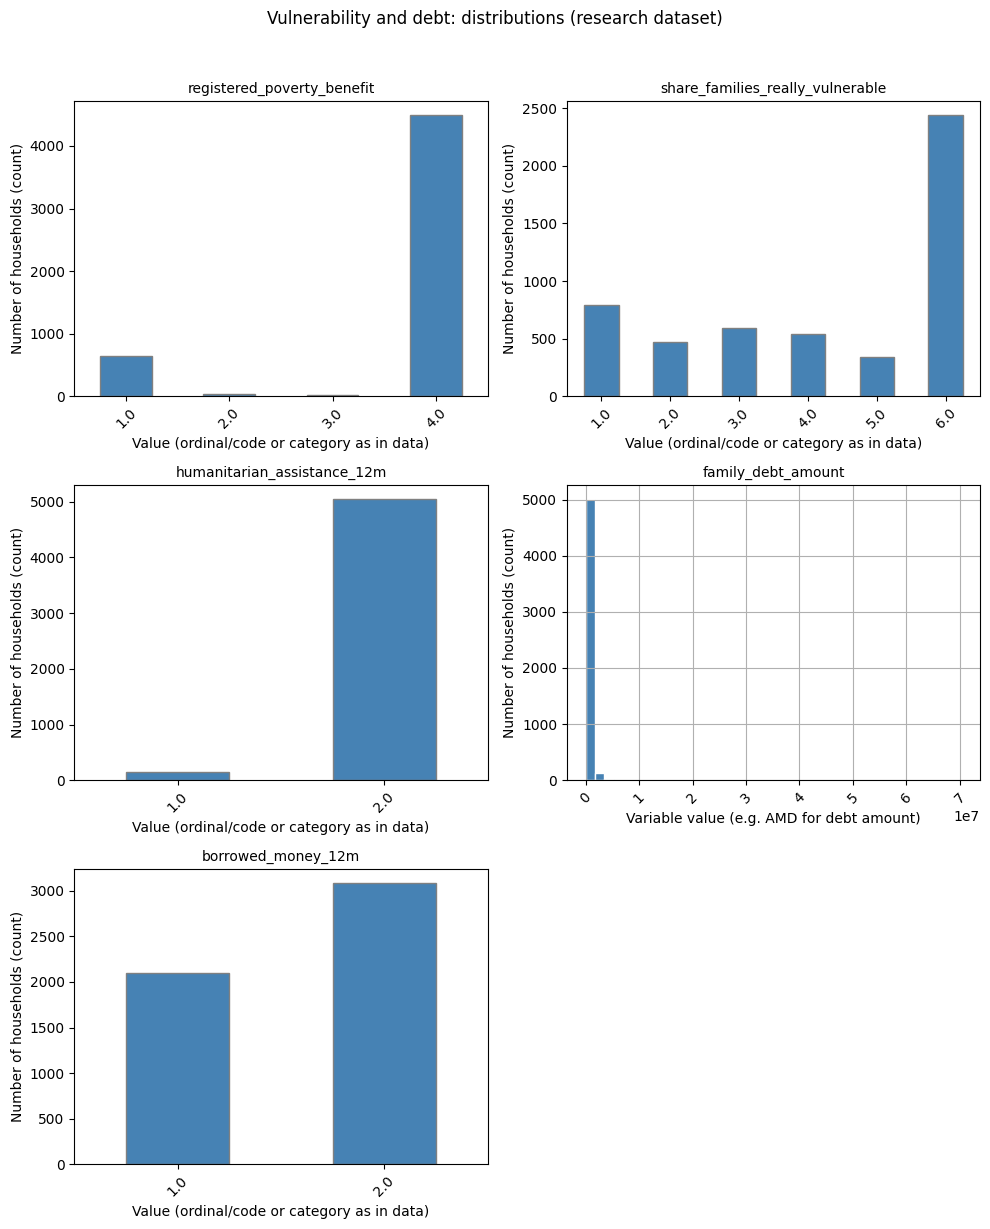

In [70]:
# Vulnerability and debt-related variables
vuln_cols = ["registered_poverty_benefit", "share_families_really_vulnerable", "humanitarian_assistance_12m", "family_debt_amount", "borrowed_money_12m"]
vuln_cols = [c for c in vuln_cols if c in df.columns]
if vuln_cols:
    n = min(5, len(vuln_cols))
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    fig.suptitle("Vulnerability and debt: distributions (research dataset)", fontsize=12, y=1.02)
    axes = axes.ravel()  # 2 plots per row
    for i, col in enumerate(vuln_cols[:6]):
        ax = axes[i]
        ser = df[col].dropna()
        if ser.nunique() <= 15:
            ser.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="gray")
            ax.set_xlabel("Value (ordinal/code or category as in data)")
        else:
            ser.hist(ax=ax, bins=40, color="steelblue", edgecolor="white")
            ax.set_xlabel("Variable value (e.g. AMD for debt amount)")
        ax.set_ylabel("Number of households (count)")
        ax.set_title(col, fontsize=10)
        ax.tick_params(axis="x", rotation=45)
    for j in range(len(vuln_cols[:6]), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()